In [1]:
# Reload other .py files without having to restart the kernel
%load_ext autoreload
%autoreload 2

In [2]:
import kagglehub, pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

# Make sure API token is stored in .kaggle/kaggle.json
# Download latest version
MAIN_PATH = kagglehub.dataset_download("rhammell/ships-in-satellite-imagery")
print("Path to dataset files:", MAIN_PATH)

Path to dataset files: C:\Users\Nicholas\.cache\kagglehub\datasets\rhammell\ships-in-satellite-imagery\versions\9


In [3]:
df = pd.read_json(os.path.join(MAIN_PATH, 'shipsnet.json'))
df.head()

,data,labels,locations,scene_ids
0,"[82, 89, 91, 87, 89, 87, 86, 86, 86, 86, 84, 8...",1,"[-118.2254694333423, 33.73803725920789]",20180708_180909_0f47
1,"[76, 75, 67, 62, 68, 72, 73, 73, 68, 69, 69, 6...",1,"[-122.33222866289329, 37.7491755586813]",20170705_180816_103e
2,"[125, 127, 129, 130, 126, 125, 129, 133, 132, ...",1,"[-118.14283073363218, 33.736016066914175]",20180712_211331_0f06
3,"[102, 99, 113, 106, 96, 102, 105, 105, 103, 10...",1,"[-122.34784341495181, 37.76648707436548]",20170609_180756_103a
4,"[78, 76, 74, 78, 79, 79, 79, 82, 86, 85, 83, 8...",1,"[-122.34852408322172, 37.75878462398653]",20170515_180653_1007


In [4]:
# According to the kaggle page, each sample is stored in a (80*80*3,) array where the first 6400
# values are the red channel of the image stored in row-major order, so the first 80 values are the 
# top row of the red channel. Could just load this from the image itself but I'm feeling goofy
# so we're gonna do it the stupid way.

# Convert the data to an array and get a Series as output
numpySeries = df['data'].apply(np.array) # similar to map(func, iterable)
print(numpySeries.shape)

# Stack all the data along axis 0. Remember that axis 0 is actually the vertical direction
arr = np.stack(numpySeries, axis=0)
print(arr.shape)

# Reshape in Fortran order where the first index changes fastest. 
# We will read 80 reds of the first row
# We will then read 80 of those red columns meaning we traversed 6400 values total
# Finally, we will go to the next axis index to start the green channel.
images = np.reshape(arr, (-1, 80, 80, 3), order='F')
print(images.shape)

# Didn't realize this at the time, but we can just reshape each element in place if we wanted
# df['data'] = df['data'].apply(lambda x: np.reshape(np.array(x), (80, 80, 3), order='F'))

(4000,)
(4000, 19200)
(4000, 80, 80, 3)


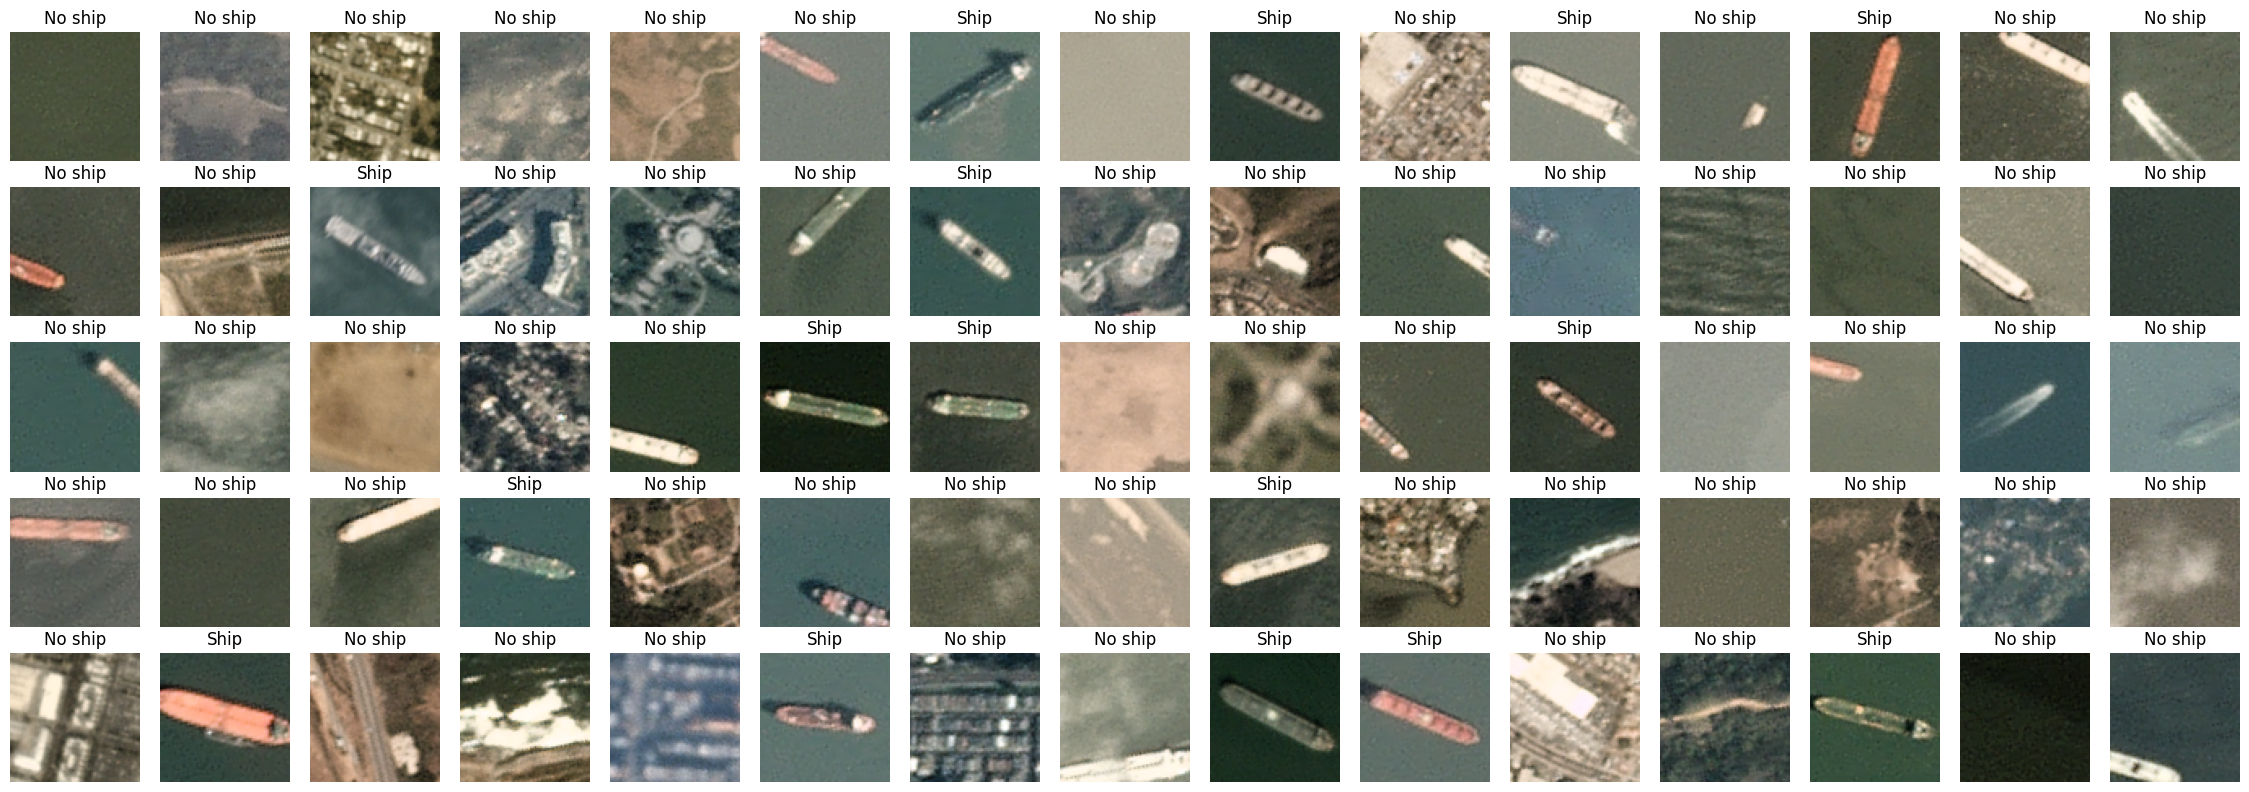

In [5]:
from K2.DisplayUtils import plotImageGridClassification

r, c = 5, 15
plotShape = (r, c)
figsize = (c*1.5, r*1.5)

labelNames = {
    0: 'No ship',
    1: 'Ship'
}

randomIndices = np.random.choice(np.arange(len(df)), (r*c,), replace=False)
samples = [np.reshape(df['data'][i], (80, 80, 3), order='F') for i in randomIndices]
labels = [labelNames[df['labels'][i]] for i in randomIndices]

plotImageGridClassification(
    samples, 
    labels,
    plotShape=plotShape, 
    figsize=figsize, 
    subplots_adjust={
            'left': 0,
            'bottom': 0,
            'right': 1,
            'top': 1,
            'hspace': 0.2,
            'wspace': 0
    })

# Defining Training Infrastructure

In [6]:
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split

# First, get entire dataset into tensor format since the entire thing can fit into memory.
reshaped = df['data'].apply(lambda x: np.reshape(np.array(x), (3, 80, 80)))
X = np.stack(reshaped, axis=0)

print(f'Data shape: {X.shape}')
print(f'Data dtype: {X.dtype}')

Y = np.stack(df['labels'])
print(f'Labels shape: {Y.shape}')
print(f'Labels dtype: {X.dtype}')

# For images, the standard data type is uint8 while labels are longs or int64s
fullDataset = TensorDataset(torch.Tensor(X).to(torch.uint8), torch.Tensor(Y).to(torch.int64))

trainValTestSplit = [0.8, 0.1, 0.1]
trainDataset, validationDataset, testDataset = random_split(fullDataset, trainValTestSplit, generator=torch.Generator().manual_seed(42))

print(f'Train length: {len(trainDataset)}')
print(f'Validation length: {len(validationDataset)}')
print(f'Test length: {len(testDataset)}')

trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=True, pin_memory=True)
valLoader = DataLoader(validationDataset, batch_size=1, shuffle=False)
testLoader = DataLoader(testDataset, batch_size=1, shuffle=False)

Data shape: (4000, 3, 80, 80)
Data dtype: int64
Labels shape: (4000,)
Labels dtype: int64
Train length: 3200
Validation length: 400
Test length: 400


## Sanity Check for DataLoader format

x.shape=(64, 3, 80, 80), y.shape=(64,)


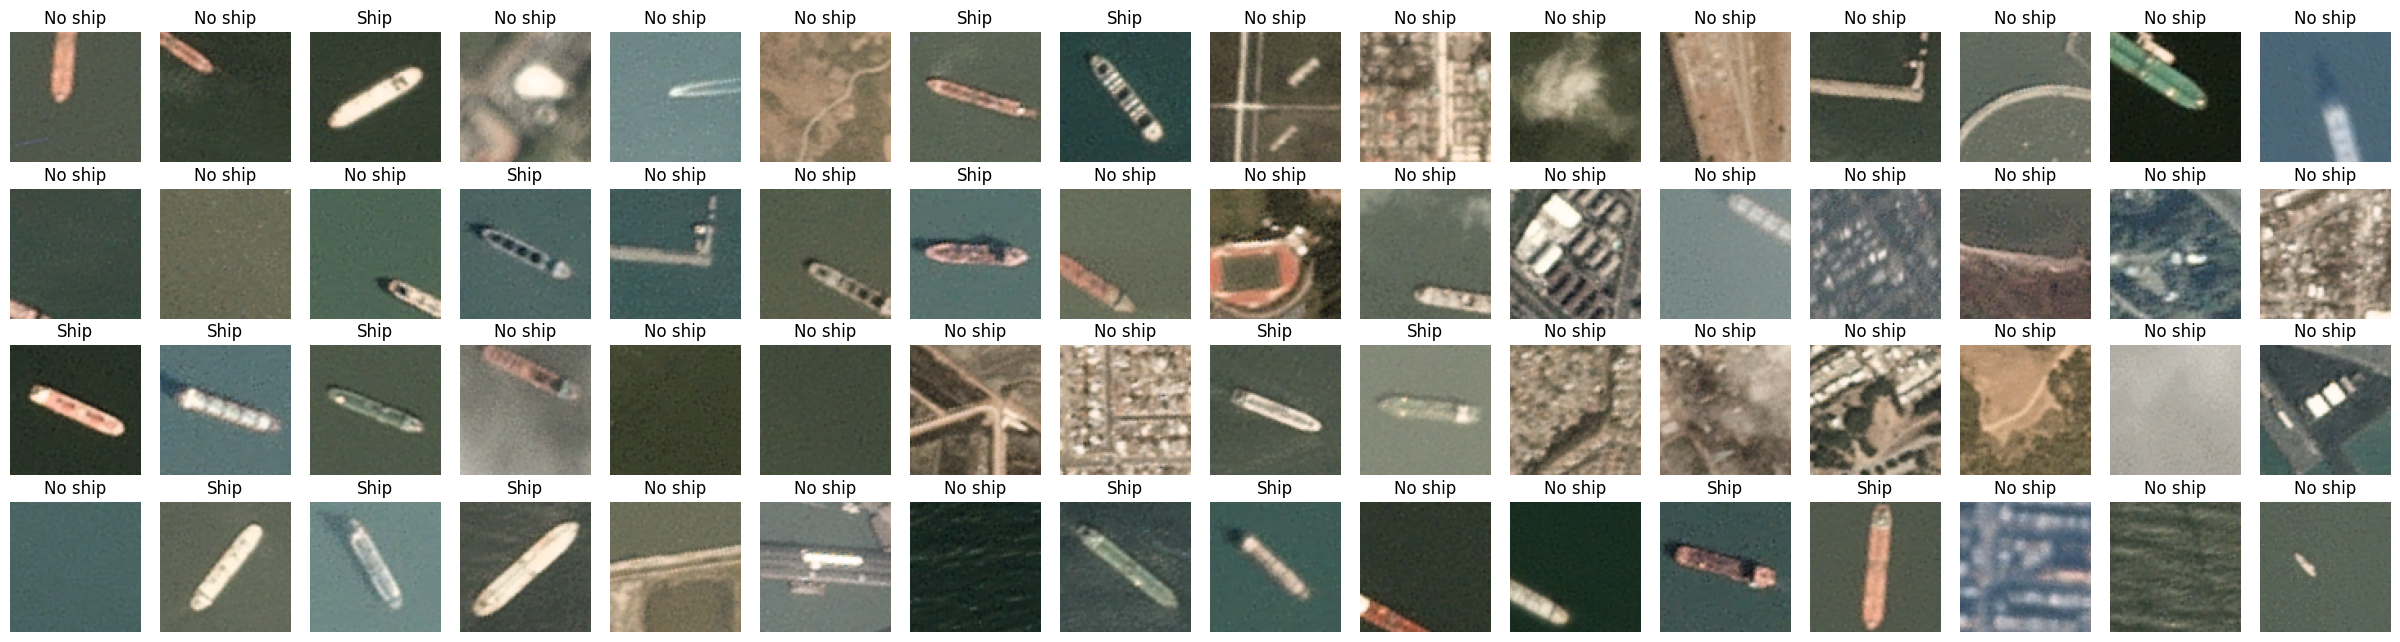

In [7]:
x, y = next(iter(trainLoader))
x: torch.Tensor
y: torch.Tensor
x, y = x.numpy().astype(np.int32), y.numpy().astype(np.int32)
print(f'{x.shape=}, {y.shape=}')

r, c = 4, 16
plotShape = (r, c)
figsize = (c*1.5, r*1.5)

labelNames = {
    0: 'No ship',
    1: 'Ship'
}

samples = [x[i].T for i in range(x.shape[0])]
labels = [labelNames[y[i]] for i in range(y.shape[0])]

plotImageGridClassification(
    samples, 
    labels,
    plotShape=plotShape, 
    figsize=figsize, 
    subplots_adjust={
            'left': 0,
            'bottom': 0,
            'right': 1,
            'top': 1,
            'hspace': 0.2,
            'wspace': 0
    })

# Visualize data augmentation methods

x.shape=torch.Size([64, 3, 80, 80]), y.shape=torch.Size([64])
x.dtype=torch.uint8, y.dtype=torch.int64
transformedSamples[0].dtype=torch.float32
samples[0].dtype=dtype('float32')


c:\Users\Nicholas\anaconda3\envs\ComputerVision\Lib\site-packages\torchvision\tv_tensors\_tv_tensor.py:77: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:3729.)
  output = func(*args, **kwargs or dict())
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.19483985..1.0000001].


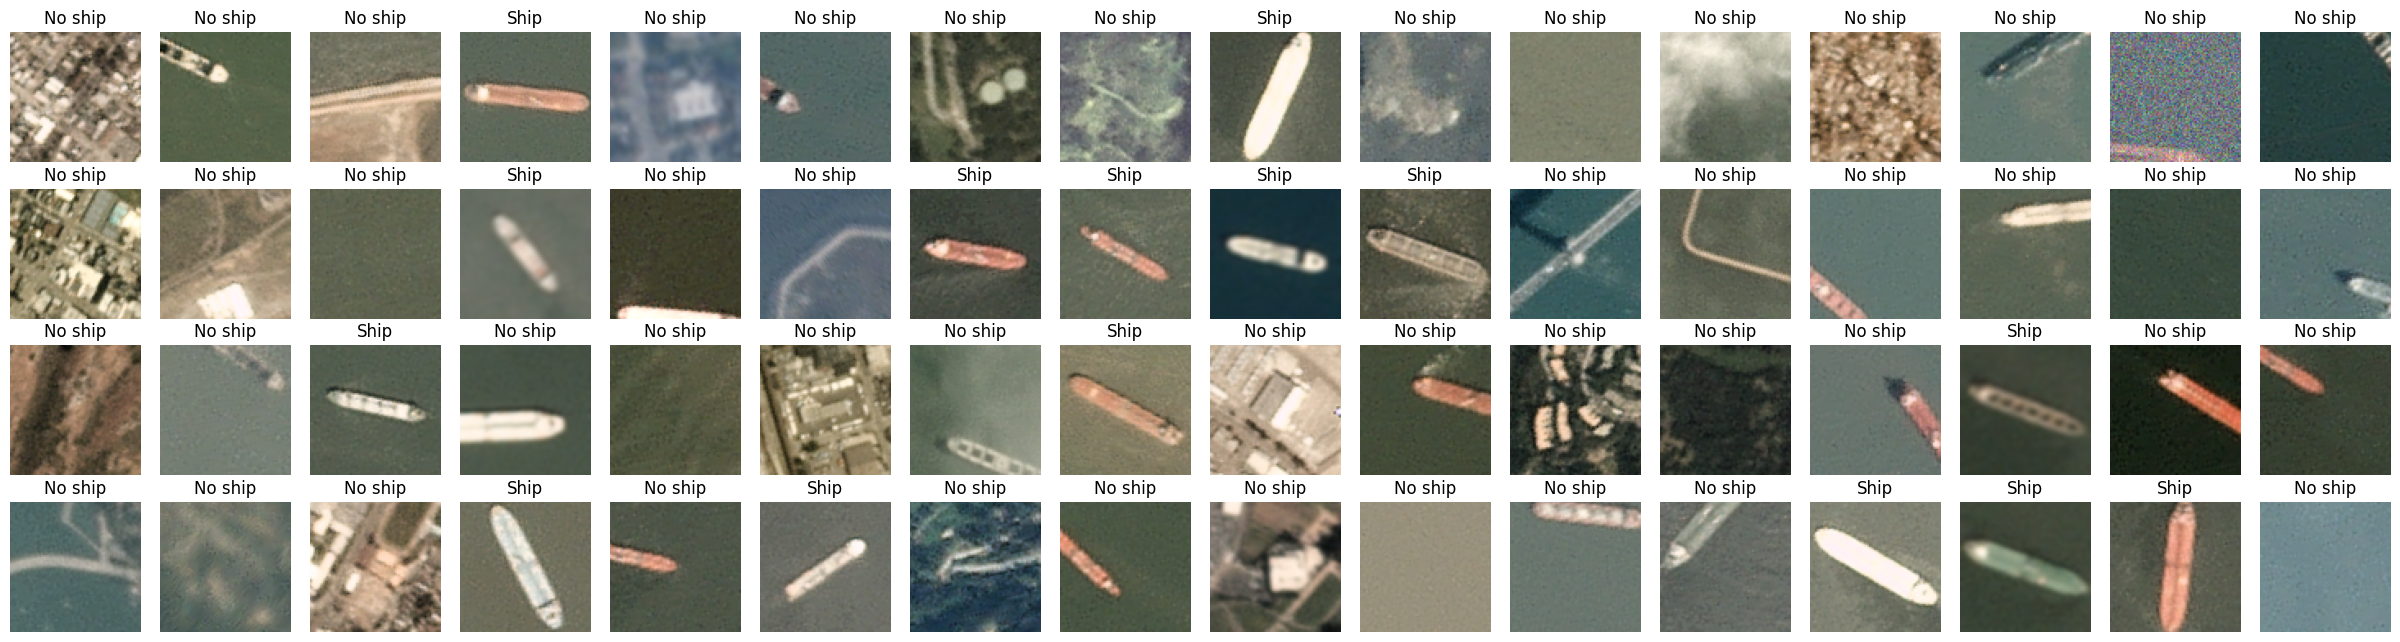

In [8]:
import torchvision.transforms.v2 as v2

x, y = next(iter(trainLoader))
x: torch.Tensor
y: torch.Tensor
print(f'{x.shape=}, {y.shape=}')
print(f'{x.dtype=}, {y.dtype=}')


possibleTransforms = [
    (v2.GaussianBlur(kernel_size=5, sigma=(0.1,2))                                                          , 1),
    (v2.RandomHorizontalFlip(p=1)                                                                           , 1),
    (v2.RandomVerticalFlip(p=1)                                                                             , 1),
    (v2.ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.2,0.2))      , 1),
    (v2.GaussianNoise()                                                                                     , 1),
    (v2.Identity()                                                                                          , 15)
]

possibleTransforms = {
    'transforms': [t[0] for t in possibleTransforms],
    'p': [t[1] for t in possibleTransforms]
}

transform = v2.Compose([
    
    v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
    v2.RandomChoice(**possibleTransforms),
    v2.Resize((80, 80))
])


transformedSamples = [transform(x[i]) for i in range(x.shape[0])]
samples = [s.T.numpy() for s in transformedSamples]
labels = [labelNames[y[i].item()] for i in range(y.shape[0])]

print(f'{transformedSamples[0].dtype=}')
print(f'{samples[0].dtype=}')



plotImageGridClassification(
    samples, 
    labels,
    plotShape=plotShape, 
    figsize=figsize, 
    subplots_adjust={
            'left': 0,
            'bottom': 0,
            'right': 1,
            'top': 1,
            'hspace': 0.2,
            'wspace': 0
    })



# Getting normalization information about the dataset

In [9]:
from NormalizationUtils import getNormalizationStats
means, stds = getNormalizationStats(trainLoader, transform=transform)
print(f'{means=}')
print(f'{stds=}')

normalizationTransform = v2.Normalize(mean=means, std=stds)

# The dataset is small enough to be normalized all at once, but we will
# normalize on the fly during training to work for extremely large datasets
# X = (X - means.reshape((1, means.shape[0], 1, 1))) / (stds.reshape((1, stds.shape[0], 1, 1)))

means=tensor([0.4110, 0.4248, 0.3736])
stds=tensor([0.1916, 0.1609, 0.1540])


# Recreate normalized datasets

In [10]:
from DataLoaders import getGPUDataLoader

trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=True, pin_memory=True)
# Try this method later, see if it is better in some cases
# trainLoader = getGPUDataLoader(trainDataset, batch_size=64) 
valLoader = DataLoader(validationDataset, batch_size=64, shuffle=False)
testLoader = DataLoader(testDataset, batch_size=64, shuffle=False)

# Model Architecture

torch.Size([64, 3, 80, 80])
torch.Size([64, 2])


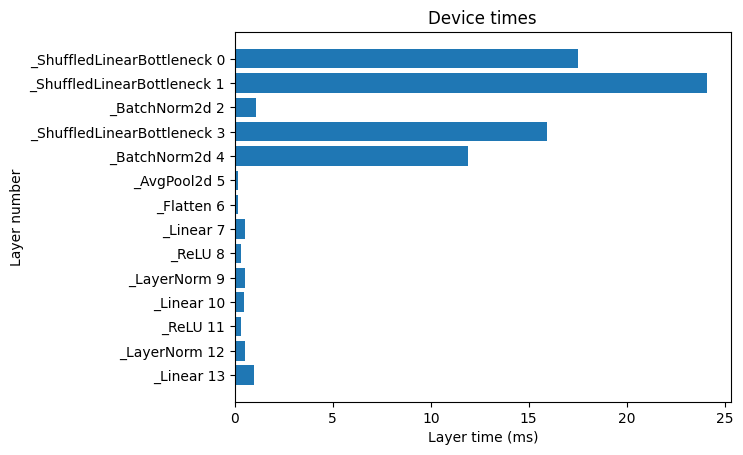

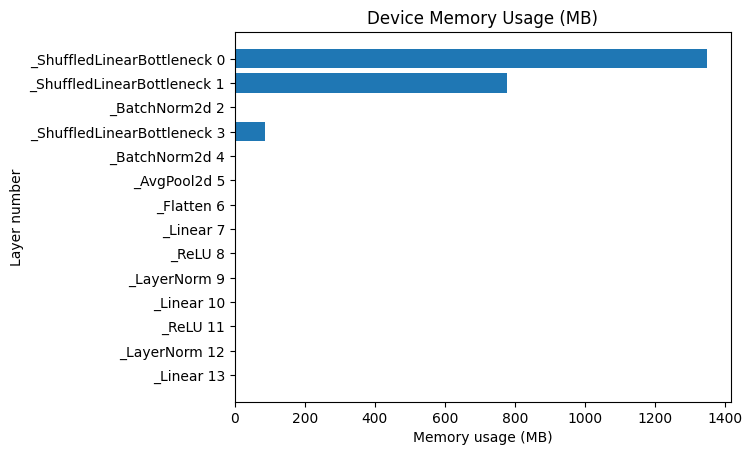

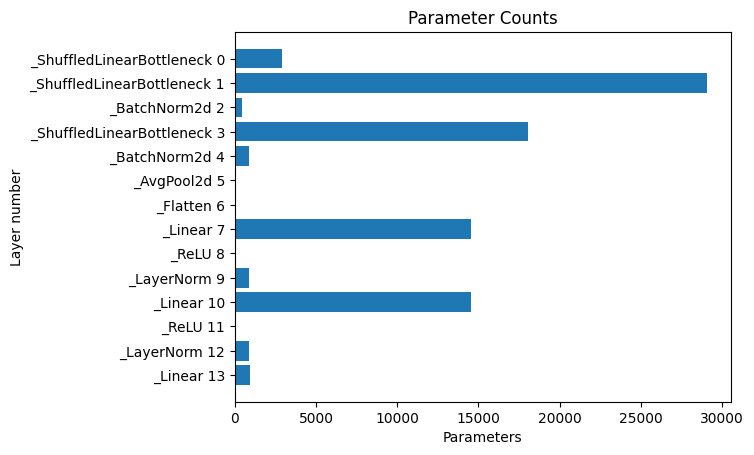

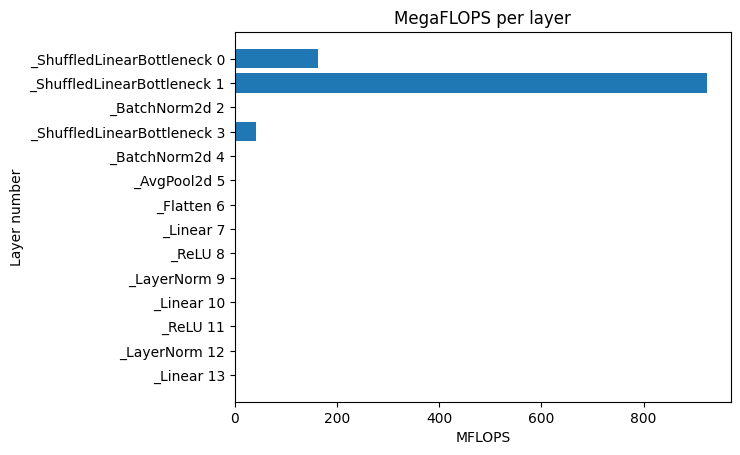

In [37]:
from Models import *
from K2.ModelProfiling import plotModelProfileGraphs

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = shuffleNetMini

model = model.to(device)
testBatch = transform(next(iter(trainLoader))[0]).to(device)
print(testBatch.shape)
output = model(testBatch)
print(output.shape)

plotModelProfileGraphs(model, input_size=(64, 3, 80, 80), printOriginalTable=False)


# Main Training Loop

In [38]:
import torch.optim as optim
import tqdm
from contextlib import nullcontext
from typing import Optional
from torch.amp import GradScaler, autocast

EPOCHS = 400
model = model.to(device)
lossFunction = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
STATS = {
    'train_loss': [],
    'train_accuracy': [],
    'validation_loss': [],
    'validation_accuracy': []
}

epoch_pbar = tqdm.notebook.tqdm(range(EPOCHS), position=0, leave=True, desc='Epochs')
train_batch_pbar = tqdm.notebook.tqdm(total=len(trainLoader), position=1, leave=True, desc='Train Batch Progress')
val_batch_pbar = tqdm.notebook.tqdm(total=len(valLoader), position=2, leave=True, desc='Validation Batch Progress')
scaler = GradScaler('cuda')

def runEpoch(
    dataloader: DataLoader,
    pbar: tqdm.tqdm,
    normalizationTransform: callable,
    augmentTransform: Optional[callable] = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
    no_grad: bool = False,
    logData: bool = True,
    statsTargets: dict = None,
):
    
    pbar.reset(total=len(dataloader))  # Reset while maintaining the total
    pbar.set_description(f'Epoch {e+1}')  # Update description to show current epoch
    numCorrect = 0
    numSamples = 0
    totalLoss = 0
    
    # Change context depending on whether we should compute gradients or not.
    context = torch.no_grad() if no_grad else nullcontext()
    with context:
        
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            
            x = normalizationTransform(augmentTransform(x))
            
            if not no_grad:
                optimizer.zero_grad()
            
            with autocast(device_type='cuda', dtype=torch.float16):
                y_hat = model(x)
                loss = lossFunction(y_hat, y)
            
            loss = scaler.scale(loss)
            
            if not no_grad:
                loss.backward()
                scaler.step(optimizer)
                scaler.update()
            
            totalLoss += loss
            numCorrect += torch.sum(y == torch.argmax(y_hat, dim=1))
            numSamples += x.shape[0]
            pbar.update(1)
        
        accuracy = numCorrect.cpu()/numSamples
        
        if logData and statsTargets:
            STATS[statsTargets['loss']].append(totalLoss.item())
            STATS[statsTargets['accuracy']].append(accuracy)
        
        return accuracy

trainStatsTargets = {
    'loss': 'train_loss',
    'accuracy': 'train_accuracy'
}

validationStatsTargets = {
    'loss': 'validation_loss',
    'accuracy': 'validation_accuracy'
}

for e in epoch_pbar:
    runEpoch(
        dataloader=trainLoader, 
        pbar=train_batch_pbar, 
        statsTargets=trainStatsTargets,
        normalizationTransform=normalizationTransform,
        augmentTransform=transform
    )
    
    with torch.no_grad():
        runEpoch(
            dataloader=valLoader, 
            pbar=val_batch_pbar, 
            statsTargets=validationStatsTargets,
            normalizationTransform=normalizationTransform,
            no_grad=True
        )


train_batch_pbar.close()
val_batch_pbar.close()
epoch_pbar.close()

# for k, v in STATS.items():
#     plt.plot(v)
#     plt.title(k)
#     plt.show()


accuracy = runEpoch(
    dataloader=valLoader, 
    pbar=val_batch_pbar, 
    statsTargets=None,
    normalizationTransform=normalizationTransform,
    no_grad=True,
    logData=False
)

print(f'Validation Accuracy: {accuracy*100:.3f}')

Epochs:   0%|          | 0/400 [00:00<?, ?it/s]

Train Batch Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Validation Batch Progress:   0%|          | 0/7 [00:00<?, ?it/s]

Validation Accuracy: 96.500


# Model Analysis

## Shift Invariance Analysis

Checking if the logits are significantly affected by small pixel shifts in the input to validate the results of this paper:
https://arxiv.org/pdf/1904.11486

I also implemented the fix the paper suggests which is surprisingly just to blur before downsampling in the BlurPool block.

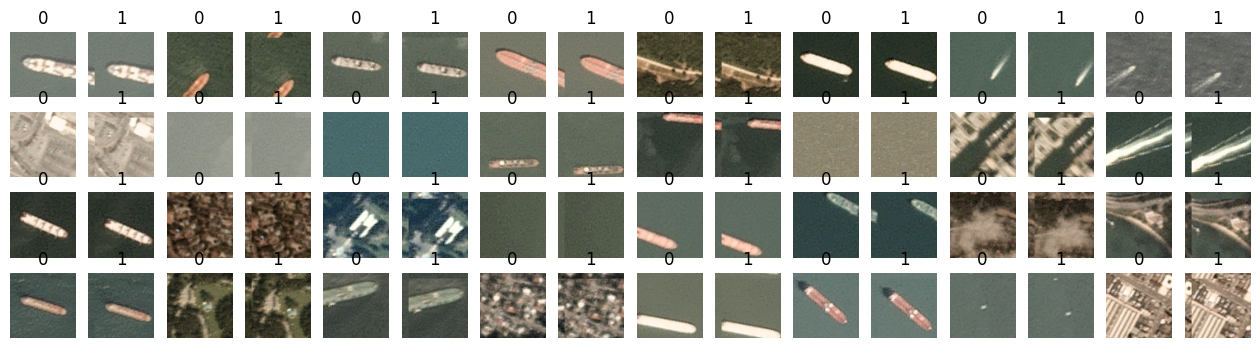

In [39]:
# Sanity check to make sure we are shifting the images properly
x, y = next(iter(valLoader))
rolled = torch.roll(x, shifts=(8, 8), dims=(2, 3))
images = []
for i in range(x.shape[0]//2):
    images.append(x[i].numpy().T)
    images.append(rolled[i].numpy().T)
labels = [0, 1] * 32 # 0 is original, 1 is shifted
plotImageGridClassification(data=images, labels=labels, plotShape=(4, 16), figsize=(16, 4))

In [40]:
from K2.Evaluations.ShiftEvaluation import getShiftLosses

shiftRange = 8
useRobustMetrics = True

shiftedStats = getShiftLosses(
    shiftRange=shiftRange,
    model=model,
    dataloader=valLoader,
    normalizationTransform=normalizationTransform,
    iterations=None
)

robustLosses = []
for lst in shiftedStats['correctProbabilities'].values():
    if useRobustMetrics:
        lowerBound = np.percentile(lst, 5)
        upperBound = np.percentile(lst, 100)
        robustLosses.append([v for v in lst if lowerBound <= v <= upperBound])
    else:
        robustLosses.append(lst)
    

# plt.figure(figsize=(shiftRange, 5))
# plt.boxplot(robustLosses, tick_labels=shiftedStats['correctProbabilities'].keys(), sym='', showmeans=False)
# plt.ylim(0.985, 1)
# plt.title('Probability of Correct Class')
# plt.ylabel('Probability predicted')
# plt.xlabel('Shift magnitude')
# plt.show()


# plt.figure(figsize=(shiftRange, 5))
# plt.plot(shiftedStats['F1'].values())
# plt.xticks([i for i in range(len(shiftedStats['F1'].keys()))], shiftedStats['F1'].keys())
# plt.ylim(0.5, 1)
# plt.title('F1 Scores per Shift Magnitude')
# plt.ylabel('F1 Score per batch')
# plt.xlabel('Shift magnitude')
# plt.show()

rawF1Scores = list(shiftedStats['F1'].values())
areaUnderF1Curve = np.trapezoid(rawF1Scores, np.arange(len(rawF1Scores)))
print(f'{float(areaUnderF1Curve)=}')




float(areaUnderF1Curve)=6.891789972782135


In [41]:
# Based on this very limited dataset, shiftNet appears to be a bit more shift invariant when compared to separableNet
# [6.1424694657325745, 6.129071190953255, 6.441969186067581, 6.296380668878555, 6.20097029209137, 6.511887580156326] # separableNet
# [6.746442824602127, 6.867224603891373, 6.547547399997711, 6.77752086520195, 6.7316902577877045, 6.7867624163627625] # shiftNet
# [6.338183373212814, 6.4586611688137054, 6.512137353420258, 6.407337099313736, 6.258924126625061, 6.369649410247803] # ShiftnetV2